# Etapa 2: Análisis Estadístico y Visualización

En este notebook se realiza la integración de los datos limpios de las diferentes variables meteorológicas y contaminantes, seguido de un análisis estadístico y generación de gráficos paso a paso.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
import os

warnings.filterwarnings('ignore')

plt.rcParams.update({'font.size': 10, 'figure.dpi': 100, 'savefig.dpi': 300,
                     'savefig.bbox': 'tight', 'figure.figsize': (12, 7)})

# Permitir visualización inline en las celdas
%matplotlib inline

BASE = 'data/processed/variables'
OUT  = 'results/figures'
os.makedirs(OUT, exist_ok=True)

## 1. Carga de Archivos Parquet
Se cargan los datos limpios de la Etapa 1.

In [2]:
archivos = {
    'O3':   f'{BASE}/O3_clean.parquet',
    'PM2.5': f'{BASE}/PM2.5_clean.parquet',
    'PM10': f'{BASE}/PM10_clean.parquet',
    'SR':   f'{BASE}/SR_clean.parquet',
    'TOUT': f'{BASE}/TOUT_clean.parquet',
}

dfs = {}
for nombre, ruta in archivos.items():
    df = pd.read_parquet(ruta)
    dfs[nombre] = df
    print(f"--- {nombre} ---")
    print(f"Filas: {len(df):,}")
    print(f"Estaciones únicas: {df['Estacion'].nunique()}\n")

--- O3 ---
Filas: 643,436
Estaciones únicas: 15

--- PM2.5 ---
Filas: 564,250
Estaciones únicas: 15

--- PM10 ---
Filas: 719,672
Estaciones únicas: 15

--- SR ---
Filas: 725,814
Estaciones únicas: 15

--- TOUT ---
Filas: 701,649
Estaciones únicas: 15



## 2. Integración y Limpieza
Unimos los dataframes secuencialmente utilizando un `inner join` por Fecha y Estación.

In [3]:
merged = dfs['O3'].copy()
for nombre in ['PM2.5', 'PM10', 'SR', 'TOUT']:
    merged = merged.merge(dfs[nombre], on=['Date', 'Estacion'], how='inner')

merged = merged.dropna()
merged = merged.drop_duplicates(subset=['Date', 'Estacion'])

print(f"Dataset final: {len(merged):,} filas y {merged.shape[1]} columnas.")
num_cols = [c for c in merged.columns if c not in ['Date', 'Estacion']]
print(f"Variables numéricas: {num_cols}")

merged.head()

Dataset final: 456,519 filas y 7 columnas.
Variables numéricas: ['O3', 'PM2.5', 'PM10', 'SR', 'TOUT']


,Date,Estacion,O3,PM2.5,PM10,SR,TOUT
0,2020-01-01 01:00:00,CE,19.0,85.639999,112.010002,0.158,10.49
1,2020-01-01 02:00:00,CE,18.0,72.389999,100.010002,0.156,10.51
2,2020-01-01 03:00:00,CE,14.0,70.250000,106.199997,0.158,10.64
3,2020-01-01 04:00:00,CE,5.0,93.720001,141.860001,0.163,10.73
4,2020-01-01 05:00:00,CE,3.0,83.930000,122.239998,0.163,10.87


## 3. Análisis Estadístico Descriptivo
Calculamos estadísticos clave para cada variable numérica.

In [4]:
stats_list = []
for col in num_cols:
    s = merged[col]
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_outliers = ((s < lower) | (s > upper)).sum()
    
    moda_val = s.round(1).mode()
    moda_str = moda_val.iloc[0] if len(moda_val) > 0 else np.nan
    
    stats_list.append({
        'Variable': col, 'N': len(s), 'Promedio': round(s.mean(), 4),
        'Mediana': round(s.median(), 4), 'Moda': moda_str,
        'Desv. Est': round(s.std(), 4), 'Rango': round(s.max() - s.min(), 4), 
        'Q1': round(q1, 4), 'Q3': round(q3, 4), 'IQR': round(iqr, 4),
        'Outliers (%)': round(100 * n_outliers / len(s), 2)
    })

pd.DataFrame(stats_list)

,Variable,N,Promedio,Mediana,Moda,Desv. Est,Rango,Q1,Q3,IQR,Outliers (%)
0,O3,456519,27.217600,23.000000,16.0,19.248400,183.000000,13.00,37.00,24.00,2.75
1,PM2.5,456519,20.401400,17.000000,10.0,15.324300,999.000000,10.47,26.35,15.88,3.70
2,PM10,456519,60.918598,52.000000,39.0,40.800999,997.000000,36.00,74.00,38.00,4.76
3,SR,456519,0.148500,0.008000,0.0,0.219300,1.252000,0.00,0.25,0.25,5.23
4,TOUT,456519,23.593399,24.219999,24.4,7.003100,51.119999,19.18,28.45,9.27,0.88


### Frecuencia de registros por Estación

In [5]:
freq = merged['Estacion'].value_counts().reset_index()
freq.columns = ['Estacion', 'Conteo']
freq['% Relativo'] = round(100 * freq['Conteo'] / freq['Conteo'].sum(), 2)
freq.sort_values('Estacion')

,Estacion,Conteo,% Relativo
2,CE,42013,9.20
11,NE,27433,6.01
10,NE2,27554,6.04
14,NE3,1992,0.44
12,NO,18208,3.99
7,NO2,33215,7.28
13,NO3,3378,0.74
9,NTE,30703,6.73
5,NTE2,38189,8.37
4,SE,41044,8.99


## 4. Análisis de Correlación
Correlaciones de Pearson y Spearman entre contaminantes.

In [6]:
corr_pearson = merged[num_cols].corr(method='pearson')
print("--- Correlación Pearson ---")
display(corr_pearson.round(4))

corr_spearman = merged[num_cols].corr(method='spearman')
print("\n--- Correlación Spearman ---")
display(corr_spearman.round(4))

--- Correlación Pearson ---


,O3,PM2.5,PM10,SR,TOUT
O3,1.0000,0.0080,0.0143,0.5304,0.4880
PM2.5,0.0080,1.0000,0.6057,0.1242,0.0141
PM10,0.0143,0.6057,1.0000,0.1253,0.0178
SR,0.5304,0.1242,0.1253,1.0000,0.3923
TOUT,0.4880,0.0141,0.0178,0.3923,1.0000



--- Correlación Spearman ---


,O3,PM2.5,PM10,SR,TOUT
O3,1.0000,-0.0362,0.0036,0.4547,0.5072
PM2.5,-0.0362,1.0000,0.6334,0.1763,0.0722
PM10,0.0036,0.6334,1.0000,0.1760,0.0836
SR,0.4547,0.1763,0.1760,1.0000,0.3458
TOUT,0.5072,0.0722,0.0836,0.3458,1.0000


### Correlación O3 vs PM por Estación

In [7]:
corr_by_est = []
for est in sorted(merged['Estacion'].unique()):
    sub = merged[merged['Estacion'] == est]
    if len(sub) > 10:
        corr_by_est.append({
            'Estacion': est, 
            'O3 vs PM2.5': round(sub['O3'].corr(sub['PM2.5']), 4), 
            'O3 vs PM10': round(sub['O3'].corr(sub['PM10']), 4), 
            'n': len(sub)
        })
pd.DataFrame(corr_by_est)

,Estacion,O3 vs PM2.5,O3 vs PM10,n
0,CE,-0.0411,0.0421,42013
1,NE,-0.0789,0.0035,27433
2,NE2,0.1173,0.0279,27554
3,NE3,-0.3116,-0.0453,1992
4,NO,-0.1185,-0.0701,18208
5,NO2,0.0523,0.1792,33215
6,NO3,-0.0081,0.1548,3378
7,NTE,-0.0884,-0.0691,30703
8,NTE2,0.1241,-0.0143,38189
9,SE,0.0753,0.2103,41044


## 5. Visualizaciones

### 5.1 Boxplots por estación

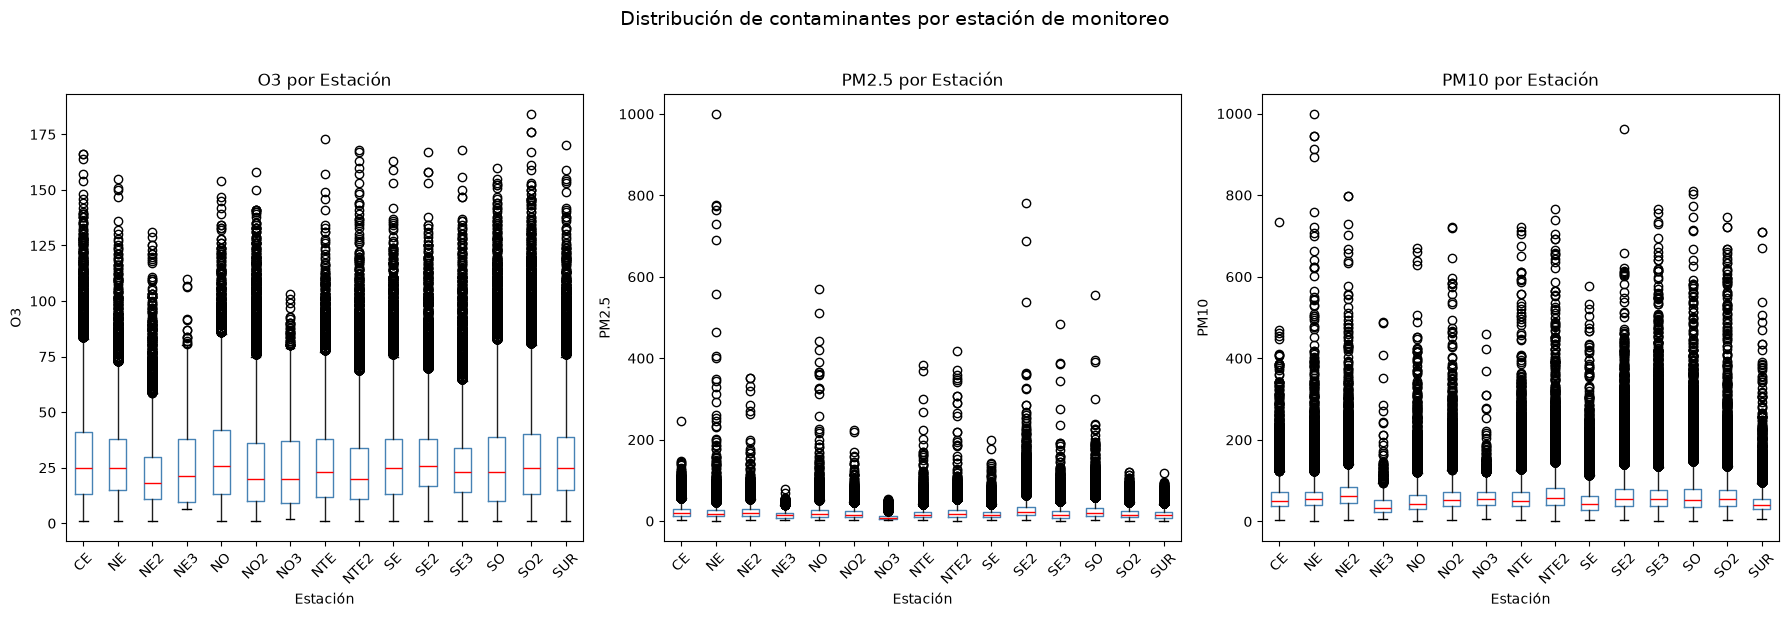

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, var in zip(axes, ['O3', 'PM2.5', 'PM10']):
    merged.boxplot(column=var, by='Estacion', ax=ax, grid=False,
                   boxprops=dict(color='steelblue'), medianprops=dict(color='red'))
    ax.set_title(f'{var} por Estación', fontsize=12)
    ax.set_xlabel('Estación')
    ax.set_ylabel(var)
    ax.tick_params(axis='x', rotation=45)
fig.suptitle('Distribución de contaminantes por estación de monitoreo', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(f'{OUT}/boxplot_estaciones.png')
plt.show()

### 5.2 Histogramas y Curvas de Densidad (KDE)

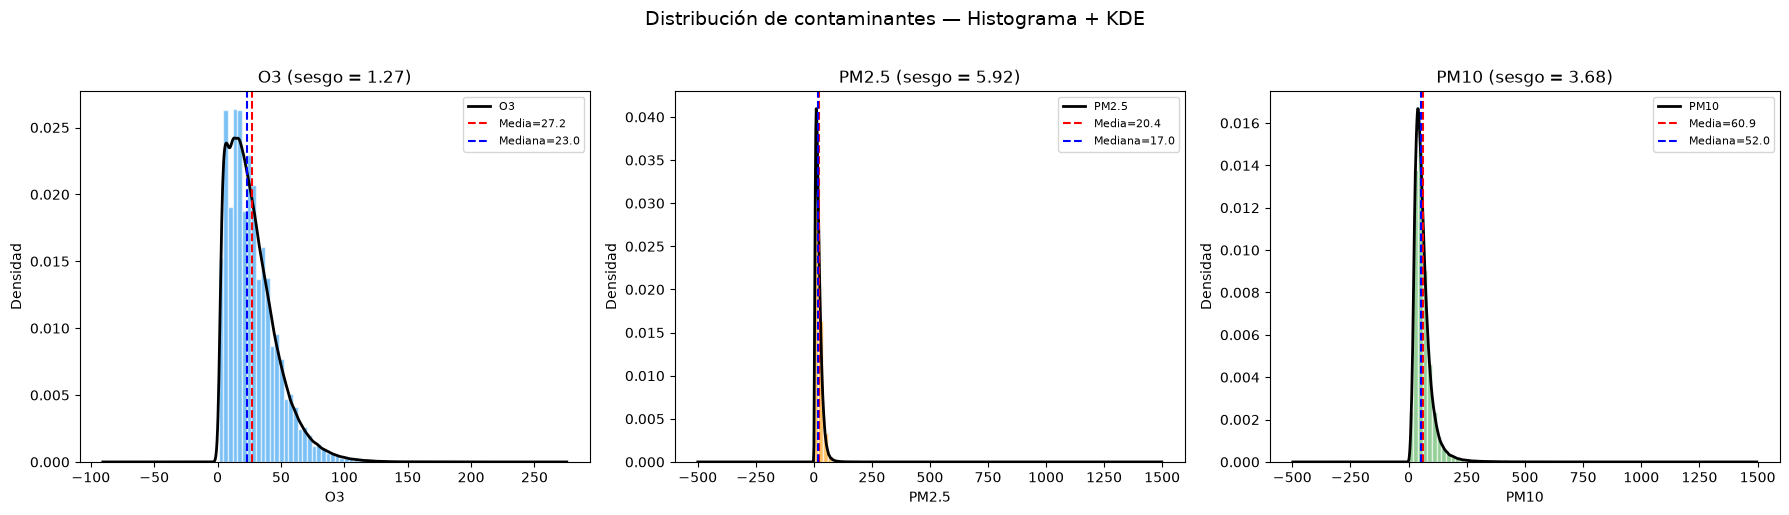

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, var, color in zip(axes, ['O3', 'PM2.5', 'PM10'], ['#2196F3', '#FF9800', '#4CAF50']):
    data = merged[var].dropna()
    skew_val = data.skew()
    ax.hist(data, bins=50, density=True, alpha=0.6, color=color, edgecolor='white')
    data.plot.kde(ax=ax, color='black', linewidth=2)
    ax.axvline(data.mean(), color='red', linestyle='--', label=f'Media={data.mean():.1f}')
    ax.axvline(data.median(), color='blue', linestyle='--', label=f'Mediana={data.median():.1f}')
    ax.set_title(f'{var} (sesgo = {skew_val:.2f})', fontsize=12)
    ax.set_xlabel(var)
    ax.set_ylabel('Densidad')
    ax.legend(fontsize=8)
fig.suptitle('Distribución de contaminantes — Histograma + KDE', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(f'{OUT}/histogramas_distribucion.png')
plt.show()

### 5.3 Mapa de Calor de Correlaciones

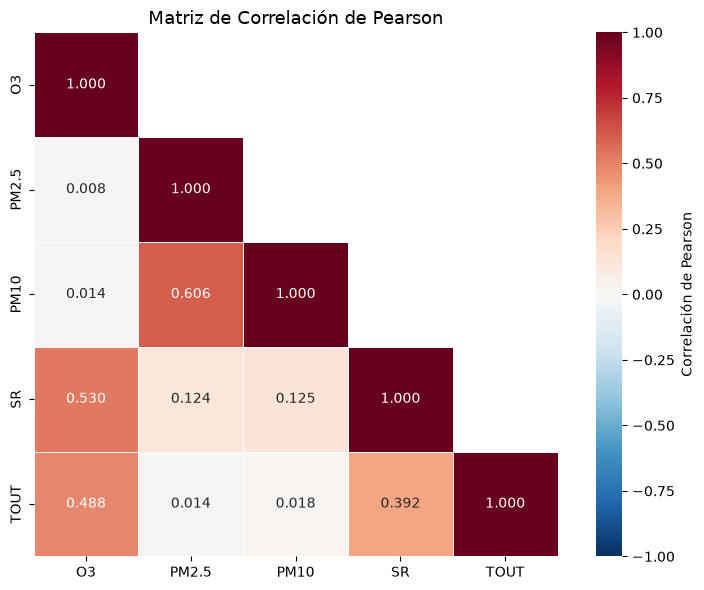

In [10]:
fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr_pearson, dtype=bool), k=1)
sns.heatmap(corr_pearson, annot=True, fmt='.3f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, square=True, linewidths=0.5, ax=ax,
            mask=mask, cbar_kws={'label': 'Correlación de Pearson'})
ax.set_title('Matriz de Correlación de Pearson', fontsize=13)
plt.tight_layout()
plt.savefig(f'{OUT}/heatmap_correlacion.png')
plt.show()

### 5.4 Distribución de Registros por Estación

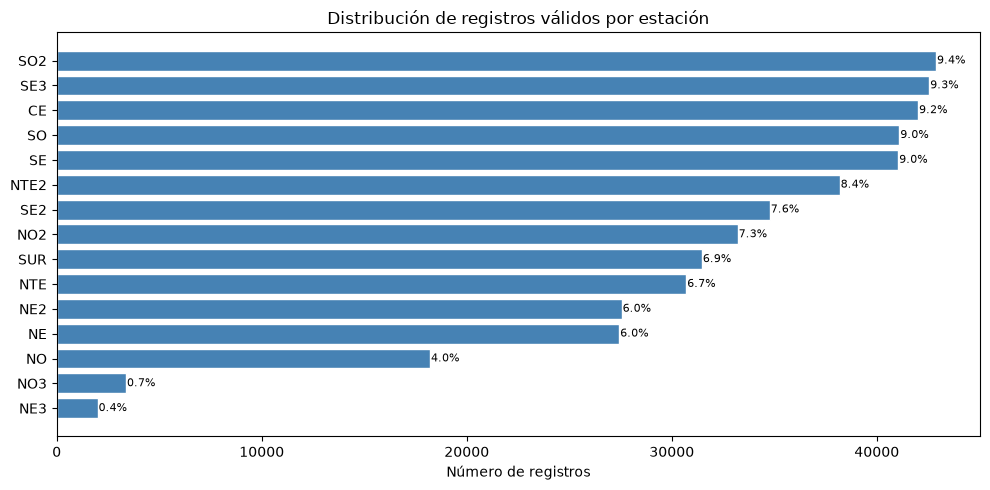

In [11]:
fig, ax = plt.subplots(figsize=(10, 5))
freq_sorted = freq.sort_values('Conteo', ascending=True)
bars = ax.barh(freq_sorted['Estacion'], freq_sorted['Conteo'], color='steelblue', edgecolor='white')
for bar, pct in zip(bars, freq_sorted['% Relativo']):
    ax.text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2, 
            f'{pct:.1f}%', va='center', fontsize=8)
ax.set_xlabel('Número de registros')
ax.set_title('Distribución de registros válidos por estación')
plt.tight_layout()
plt.savefig(f'{OUT}/piechart_estaciones.png')
plt.show()

### 5.5 Gráfico de Dispersión (PM2.5 vs O3 vs Radiación Solar)

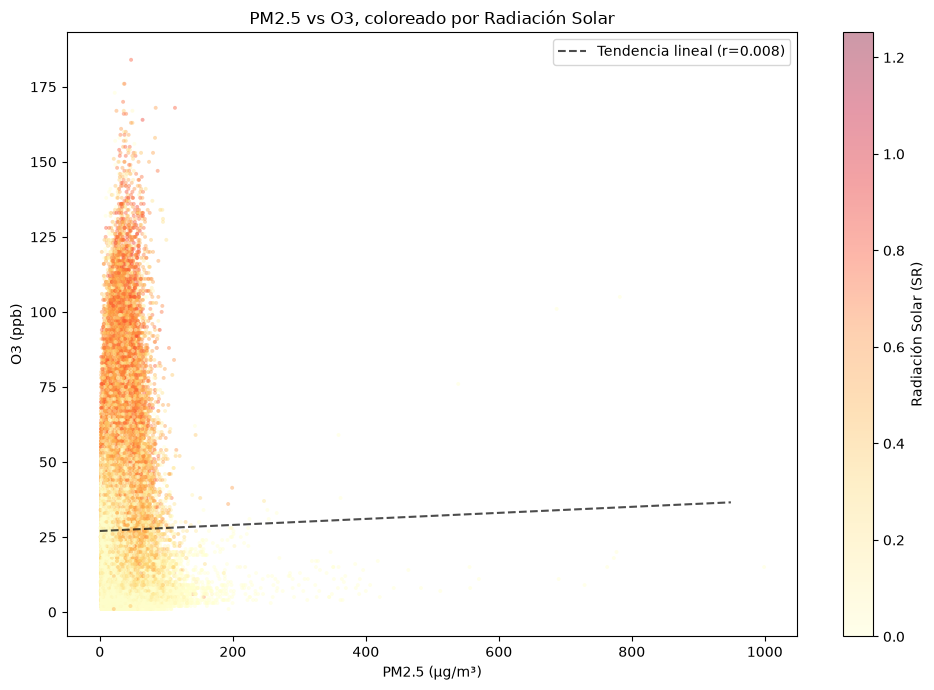

In [12]:
fig, ax = plt.subplots(figsize=(10, 7))
sc = ax.scatter(merged['PM2.5'], merged['O3'], c=merged['SR'], 
                cmap='YlOrRd', alpha=0.4, s=8, edgecolors='none')
cbar = plt.colorbar(sc, ax=ax, label='Radiación Solar (SR)')
ax.set_xlabel('PM2.5 (μg/m³)')
ax.set_ylabel('O3 (ppb)')
ax.set_title('PM2.5 vs O3, coloreado por Radiación Solar')

z = np.polyfit(merged['PM2.5'], merged['O3'], 1)
p = np.poly1d(z)
x_line = np.linspace(merged['PM2.5'].min(), merged['PM2.5'].max() * 0.95, 100)
ax.plot(x_line, p(x_line), 'k--', alpha=0.7, linewidth=1.5, 
        label=f'Tendencia lineal (r={merged["PM2.5"].corr(merged["O3"]):.3f})')
ax.legend(loc='upper right')
plt.tight_layout()
plt.savefig(f'{OUT}/scatter_pm_o3_sr.png')
plt.show()